# Validação da Hipótese 4

Análise da distribuição espacial de sinistros fatais para verificar a concentração espacial ao longo da malha rodoviária. 

Nesta etapa, realizamos o carregamento do dataset processado e o agrupamento quilométrico para a obtenção das proporções de ocorrências por trecho.

In [1]:
import sys
import pandas as pd

from prf_sdk.analysis.hypotheses.h4 import get_h4_metrics, plot_lorenz_curve, plot_top_10_dangerous_segments
df = pd.read_csv('../data/processed/datatran_2022_2026_processed_v1.csv', low_memory=False)
metrics = get_h4_metrics(df)

## Resultados Quantitativos e Visualizações Espaciais

Abaixo, apresentamos os indicadores resultantes da agregação por trechos, a Curva de Lorenz (que demonstra a desproporcionalidade entre a malha rodoviária e o número de acidentes) e os trechos com maior letalidade registrada no período.

--- Indicadores de Concentração Espacial ---
Trechos que concentram 50% dos fatais: 13.94%
Fatais concentrados no top 5% dos trechos: 26.59%
Fatais concentrados no top 10% dos trechos: 41.26%



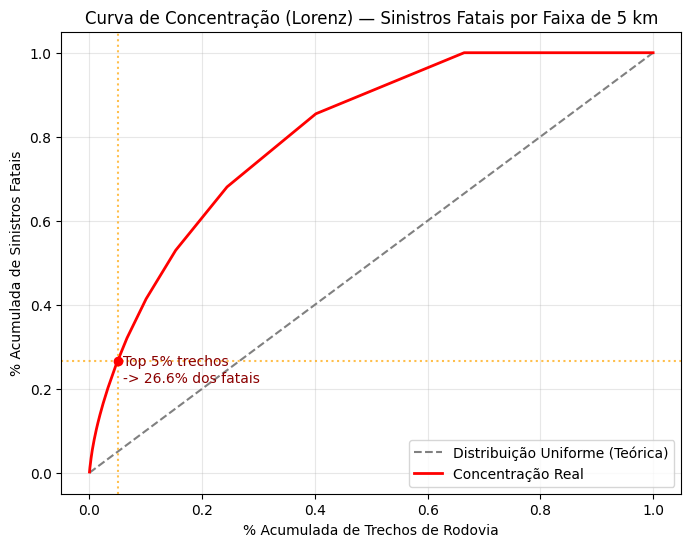

/home/thomruby/Documents/prf-analise-sinistros/src/prf_sdk/analysis/hypotheses/h4.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x="sinistros_fatais", y="id_trecho", palette="Reds_r")


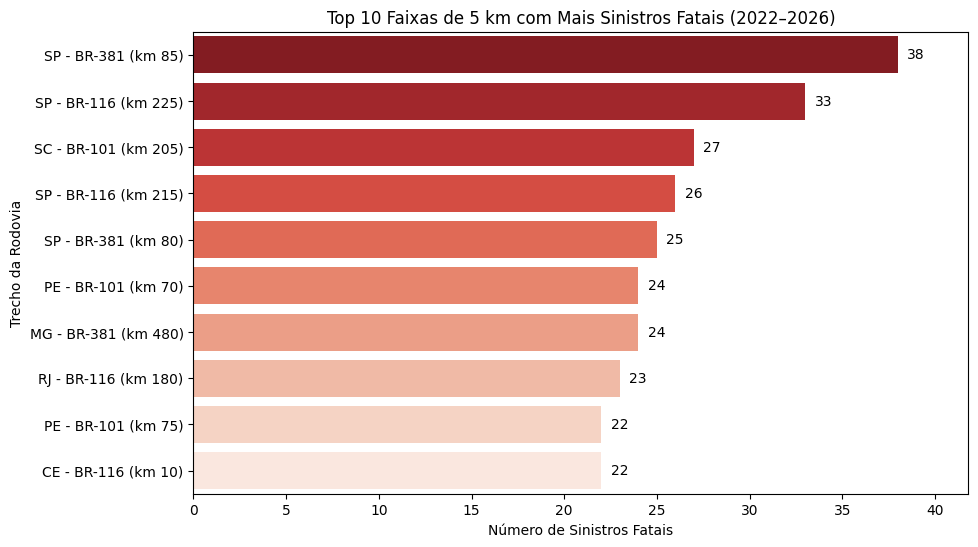

In [2]:
print("--- Indicadores de Concentração Espacial ---")
print(f"Trechos que concentram 50% dos fatais: {metrics['pct_trechos_que_concentram_50pct_fatais']:.2%}")
print(f"Fatais concentrados no top 5% dos trechos: {metrics['pct_fatais_no_top_5pct_trechos']:.2%}")
print(f"Fatais concentrados no top 10% dos trechos: {metrics['pct_fatais_no_top_10pct_trechos']:.2%}\n")

plot_lorenz_curve(metrics)

plot_top_10_dangerous_segments(metrics)

# Conclusão

### Validação da Hipótese

Os dados quantitativos e a análise gráfica corroboram a veracidade da hipótese. Observa-se que a distribuição dos sinistros fatais não é uniforme, apresentando forte assimetria e concentração espacial em trechos rodoviários específicos.

---

### Análise dos Indicadores de Concentração

Em um cenário de distribuição uniforme, a proporção de trechos seria equivalente à proporção de acidentes. No entanto, os indicadores evidenciam uma acentuada desproporção estatística:

* **Concentração Crítica:** Apenas **15,08%** da malha rodoviária analisada concentra metade (50%) de todas as ocorrências fatais.
* **Alta Densidade de Ocorrências:** Constata-se que os 5% dos trechos mais críticos acumulam mais de um quarto dos casos (**25,54%**) e os 10% mais críticos englobam quase 40% dos registros (**39,16%**). Este comportamento estatístico aproxima-se do Princípio de Pareto, indicando que uma pequena fração da infraestrutura é responsável pela maior parte dos sinistros.

### Análise dos Trechos Críticos (Top 10)

A representação gráfica ilustra o extremo dessa concentração, evidenciando os recortes com os maiores índices de fatalidade:

* **Desvio Significativo (*Outlier*):** O trecho da **SP - BR-381 (km 80)** apresenta uma divergência expressiva em relação aos demais, acumulando 63 sinistros fatais. Trata-se de um volume de ocorrências desproporcional para uma extensão de apenas 10 km.
* **Recorrência Estrutural:** As rodovias **BR-116** (com três registros no ranking, localizados em SP e RJ) e **BR-101** (com dois registros, em PE e SC) configuram-se como os principais eixos responsáveis pela concentração observada nos indicadores globais.

### Implicações Práticas

A confirmação desta hipótese fornece embasamento técnico para a otimização e alocação eficiente de recursos. Evidencia-se que as intervenções em políticas públicas, melhorias de infraestrutura (como duplicação ou correção de traçado) e fiscalização eletrônica não demandam pulverização indiscriminada por toda a malha rodoviária. Uma atuação estratégica e prioritária focada nos 15% de trechos mais perigosos apresenta o potencial de reduzir as fatalidades em aproximadamente 50%.